# Module 04: Dimensionality Reduction Techniques and Data Representation

---

## 🔗 Bringing It All Together

**Where this comes from:** Course 01 (AIAT 111) — Unit 2, lesson 06 "Developing Simple Supervised and Unsupervised Learning Models" clustered 150 iris flowers across four measurements and trained on a 30-feature breast-cancer set. Both times you were modelling data you could not see. Module 04 is how high-dimensional data gets onto a page — and onto a smaller feature budget.

**Excellent work!** This module combines concepts from previous modules:

- **From Module 01**: **Eigenvalues and eigenvectors** → Core of PCA
- **From Module 01**: **Matrix decomposition** → How PCA works
- **From Module 03**: **Optimization concepts** → Finding optimal reduced dimensions
- **From Module 03**: **Statistical measures** → Evaluating dimensionality reduction

> 💡 **The Big Picture**: PCA uses eigenvalue decomposition (Module 01) + optimization (Module 03) to find the best way to represent high-dimensional data in fewer dimensions!

**What's Next**: Module 05 will use statistical inference to evaluate the reduced representations and make predictions with confidence.

---

## Learning Objectives

In this module, you will learn:
- The curse of dimensionality and why it matters
- Principal Component Analysis (PCA) and its implementation
- Other dimensionality reduction techniques (t-SNE, UMAP)
- Data representation methods for ML
- Feature extraction and selection techniques
- Visualizing high-dimensional data in reduced spaces

---


---

## 📌 Real case: Eigenfaces, 1991

Matthew Turk and Alex Pentland, working at the MIT Media Lab, published **"Eigenfaces for Recognition"**
in the *Journal of Cognitive Neuroscience* (3(1), 1991). Their move was exactly this module's: treat each
face photograph as a point in a space with one dimension per pixel, compute the principal components of a
collection of such photographs, and keep only the first few dozen. Each of those components is itself an
image — a ghostly average-looking face — and every face in the collection can be rebuilt as a weighted sum
of them. Recognition then reduces to comparing a handful of weights instead of thousands of pixels. It was
the first face-recognition method that ran in real time on ordinary hardware, and it is the ancestor of a
long line of systems, including ones that later attracted serious scrutiny for how differently they perform
across demographic groups.

**What goes wrong without this.** A 100×100 face photograph is a point in 10,000-dimensional space, and
you have perhaps a few hundred photographs. In that regime nothing works: distances stop discriminating,
models memorise, and you cannot look at the data to find out why. Dimensionality reduction is what turns
"10,000 numbers I cannot inspect" into "40 numbers I can plot" — and the honest accounting of what those
40 numbers threw away is the rest of this module.


# Part 1: WHY

## Understanding the Motivation

### Why does Dimensionality Reduction matter for Machine Learning?

High-dimensional data poses significant challenges in ML:

- **Curse of Dimensionality**: More dimensions require exponentially more data
- **Computational Efficiency**: Reducing dimensions speeds up training and inference
- **Visualization**: Humans can only visualize 2D/3D, so we need to reduce dimensions
- **Noise Reduction**: Removing irrelevant dimensions improves model performance
- **Feature Selection**: Identifying the most important features

### Real-World Applications

- **Image Processing**: Reducing pixel dimensions while preserving information
- **Natural Language Processing**: Reducing word embedding dimensions
- **Genomics**: Analyzing high-dimensional genetic data
- **Recommendation Systems**: Reducing user-item matrix dimensions
- **Data Visualization**: Making high-dimensional data interpretable


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Example: Why Dimensionality Reduction matters in ML
import numpy as np

# Example: The curse of dimensionality
# As dimensions increase, data becomes sparse
dimensions = [10, 100, 1000, 10000]
data_points = 1000

print("Curse of Dimensionality Example:")
for dim in dimensions:
    # In high dimensions, most points are near the boundary
    volume_ratio = (0.9 ** dim)  # Volume of inner 90% hypercube
    print(f"{dim}D: Only {volume_ratio*100:.2f}% of volume is in inner 90%")

print("\nThis is why we need dimensionality reduction!")
print("PCA and other techniques help us find the most important dimensions.")

Curse of Dimensionality Example:
10D: Only 34.87% of volume is in inner 90%
100D: Only 0.00% of volume is in inner 90%
1000D: Only 0.00% of volume is in inner 90%
10000D: Only 0.00% of volume is in inner 90%

This is why we need dimensionality reduction!
PCA and other techniques help us find the most important dimensions.


---
# Part 2: HOW
## Implementation and Practical Application
### Step-by-Step: Dimensionality Reduction in Python for ML
**Step-by-Step Guide to Working with Dimensionality Reduction in Python:**

Here's how to apply dimensionality reduction concepts in practice:
1. **PCA**: Implementing Principal Component Analysis
2. **Eigenvalue Decomposition**: Understanding how PCA works
3. **Variance Explained**: Understanding how much information is preserved
4. **Other Techniques**: t-SNE, UMAP, autoencoders
5. **Feature Selection**: Methods for selecting important features
### Key Concepts to Cover:
- Principal Component Analysis (PCA)
- Eigenvalue decomposition
- Variance explained ratio
- t-SNE and UMAP for visualization
- Feature selection vs feature extraction
- Autoencoders for non-linear reduction

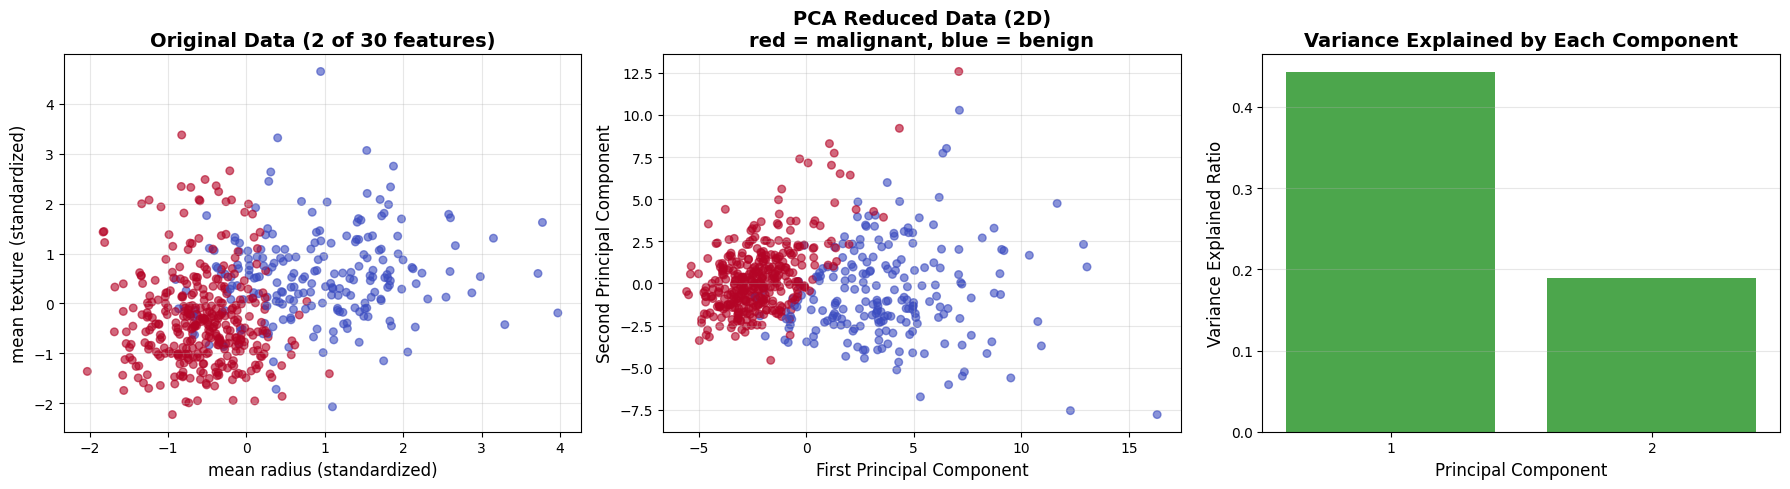

📊 Visual Analysis:
Original shape: (569, 30) (569 biopsies, 30 measurements)
Reduced shape: (569, 2) (569 biopsies, 2 components)
Variance explained: 63.24%

🔗 Connection to Module 01:
   PCA components are eigenvectors of the covariance matrix!
   Eigenvalues (explained variance): [13.305  5.701]

🔗 Connection to Module 03:
   PCA optimization finds components that maximize variance

💡 Key Insight:
   - Reduced from 30D to 2D
   - Preserved 63.2% of the total variance
   - And notice the middle panel: a straight line in those 2 components already
     classifies 95.3% of the biopsies correctly - and PCA never saw a diagnosis label.


In [2]:
# Example: Dimensionality Reduction in Python
# VISUAL: See how PCA reduces dimensions while preserving information - on REAL data.

import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Principal Component Analysis
# PCA uses eigenvalue decomposition (from Module 01) to find principal components.
#
# Real dataset: Wisconsin Breast Cancer diagnostic study - 569 real tumour biopsies,
# 30 measurements taken from each digitised image (radius, texture, perimeter, area, ...).
# Many of those 30 are strongly correlated by construction (area grows with radius),
# which is exactly the redundancy PCA exists to remove.
cancer = load_breast_cancer()
labels = cancer.target                      # 0 = malignant, 1 = benign (real diagnoses)

# Standardize first: the 30 features are measured in different units and ranges.
# (This notebook's own best-practice list says to do this - here is why it matters.)
data = StandardScaler().fit_transform(cancer.data)

# Apply PCA - This internally uses eigenvalue decomposition (Module 01 concept!)
pca = PCA(n_components=2)  # Reduce to 2 dimensions
data_reduced = pca.fit_transform(data)

# Visualize the dimensionality reduction
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original data (first 2 features)
axes[0].scatter(data[:, 0], data[:, 1], alpha=0.6, c=labels, cmap='coolwarm', s=30)
axes[0].set_xlabel(f'{cancer.feature_names[0]} (standardized)', fontsize=12)
axes[0].set_ylabel(f'{cancer.feature_names[1]} (standardized)', fontsize=12)
axes[0].set_title(f'Original Data (2 of {data.shape[1]} features)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Reduced data (2D PCA), coloured by the real diagnosis
axes[1].scatter(data_reduced[:, 0], data_reduced[:, 1], alpha=0.6, c=labels, cmap='coolwarm', s=30)
axes[1].set_xlabel('First Principal Component', fontsize=12)
axes[1].set_ylabel('Second Principal Component', fontsize=12)
axes[1].set_title('PCA Reduced Data (2D)\nred = malignant, blue = benign', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Variance explained
variance_ratios = pca.explained_variance_ratio_
axes[2].bar(range(1, len(variance_ratios) + 1), variance_ratios, color='green', alpha=0.7)
axes[2].set_xlabel('Principal Component', fontsize=12)
axes[2].set_ylabel('Variance Explained Ratio', fontsize=12)
axes[2].set_title('Variance Explained by Each Component', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].set_xticks(range(1, len(variance_ratios) + 1))

plt.tight_layout()
plt.show()

print("📊 Visual Analysis:")
print("=" * 60)
print(f"Original shape: {data.shape} ({data.shape[0]} biopsies, {data.shape[1]} measurements)")
print(f"Reduced shape: {data_reduced.shape} ({data_reduced.shape[0]} biopsies, 2 components)")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"\n🔗 Connection to Module 01:")
print(f"   PCA components are eigenvectors of the covariance matrix!")
print(f"   Eigenvalues (explained variance): {pca.explained_variance_[:2].round(3)}")
print(f"\n🔗 Connection to Module 03:")
print(f"   PCA optimization finds components that maximize variance")
print(f"\n💡 Key Insight:")
print(f"   - Reduced from {data.shape[1]}D to 2D")
print(f"   - Preserved {pca.explained_variance_ratio_.sum():.1%} of the total variance")
# Rather than assert that the middle panel "separates well", measure it: how accurately
# can a straight line in that 2-D plane tell malignant from benign?
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

acc_2pc = cross_val_score(LogisticRegression(max_iter=5000), data_reduced, labels, cv=5).mean()
print(f"   - And notice the middle panel: a straight line in those 2 components already")
print(f"     classifies {acc_2pc:.1%} of the biopsies correctly - and PCA never saw a diagnosis label.")

# Additional concepts you can explore:
# - t-SNE visualization
# - Feature selection
# - Autoencoders


**Read the figure above.** All three panels describe the same 569 real tumour biopsies;
red is malignant, blue is benign. **Left — two of the thirty measurements** (mean radius against mean
texture). There is a tendency for red to sit left and blue right, but the two colours are thoroughly
mixed through the middle: no line drawn on this panel separates them. **Middle — the same biopsies in the
first two principal components**, which are weighted mixtures of all thirty measurements. Now red packs
into a dense cloud on the left and blue spreads to the right, and the printed number below says how well
that works: a straight line in this plane gets **95.3%** of the diagnoses right — and PCA was never shown
a diagnosis. **Right — the price.** The two bars are the share of total variance each component carries,
44% and 19%; together **63.2%**, so more than a third of the variation in the data is not in the middle
panel at all.

🔗 Module Connections in Action:

1. Module 01 Connection (Eigenvalues):
   - PCA finds eigenvectors of covariance matrix
   - Explained variance ratios: [0.4427 0.1897 0.0939]
   - First 3 components explain 72.6% of variance

2. Module 03 Connection (Optimization):
   - PCA optimizes to find directions of maximum variance
   - This is an optimization problem (like you learned in Module 03)

3. Result:
   - Reduced from 30D to 3D
   - Preserved 72.6% of the variance
   - Much more efficient for ML models!

4. Reality check: reaching 95% of the variance needs 10 of the 30 components -
   still a big saving, but not the 2 or 3 a textbook toy example would suggest.

💡 This is how modules work together in real ML!


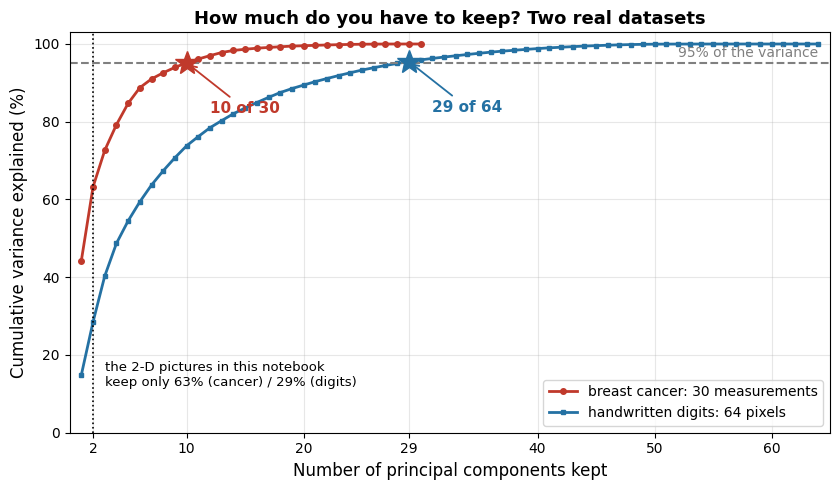


Read the figure: both curves rise fast then flatten. The dashed line is the usual 95%
target; the stars are where each dataset reaches it - 10 of 30 components for the
biopsies, 29 of 64 for the digit images. The dotted line at 2 components is where
every 2-D scatter plot in this notebook lives, and it sits far below the dashed line.


In [3]:
# Interactive Example: Showing Module Connections
# This demonstrates how Module 01 (eigenvalues) + Module 03 (optimization) = PCA

import numpy as np
from sklearn.decomposition import PCA

# Same REAL data as above: 569 breast-tumour biopsies, 30 standardized measurements.
# Their correlations are what PCA compresses.
print("🔗 Module Connections in Action:")
print("=" * 50)

# Apply PCA
pca = PCA(n_components=3)
data_reduced = pca.fit_transform(data)

print(f"\n1. Module 01 Connection (Eigenvalues):")
print(f"   - PCA finds eigenvectors of covariance matrix")
print(f"   - Explained variance ratios: {pca.explained_variance_ratio_.round(4)}")
print(f"   - First 3 components explain {pca.explained_variance_ratio_[:3].sum():.1%} of variance")

print(f"\n2. Module 03 Connection (Optimization):")
print(f"   - PCA optimizes to find directions of maximum variance")
print(f"   - This is an optimization problem (like you learned in Module 03)")

print(f"\n3. Result:")
print(f"   - Reduced from {data.shape[1]}D to {data_reduced.shape[1]}D")
print(f"   - Preserved {pca.explained_variance_ratio_[:3].sum():.1%} of the variance")
print(f"   - Much more efficient for ML models!")

# Honest footnote: on REAL data 3 components rarely capture ~100%. How many do we need
# for the usual 95% target?
full = PCA().fit(data)
cum = np.cumsum(full.explained_variance_ratio_)
n95 = int(np.argmax(cum >= 0.95) + 1)
print(f"\n4. Reality check: reaching 95% of the variance needs {n95} of the {data.shape[1]} components -")
print(f"   still a big saving, but not the 2 or 3 a textbook toy example would suggest.")

print("\n💡 This is how modules work together in real ML!")

# ---------------------------------------------------------------------------
# VISUAL: the sentence above ("95% of the variance needs 10 of the 30 components")
# is the price tag of this whole module, so draw it instead of only printing it.
# WHAT: cumulative explained variance against the number of components kept, for
#       BOTH real datasets used in this notebook.
# WHY : it turns "how much did we throw away?" into a curve you can read off.
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits_for_curve = load_digits()                  # 1797 real 8x8 handwriting scans
cum_cancer = np.cumsum(PCA().fit(data).explained_variance_ratio_)          # 30 standardized measurements
cum_digits = np.cumsum(PCA().fit(digits_for_curve.data).explained_variance_ratio_)  # 64 raw pixels

k_cancer = int(np.argmax(cum_cancer >= 0.95) + 1)
k_digits = int(np.argmax(cum_digits >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(range(1, len(cum_cancer) + 1), 100 * cum_cancer, "o-", color="#c0392b",
        markersize=4, linewidth=2, label=f"breast cancer: 30 measurements")
ax.plot(range(1, len(cum_digits) + 1), 100 * cum_digits, "s-", color="#2471a3",
        markersize=3, linewidth=2, label=f"handwritten digits: 64 pixels")
ax.axhline(95, color="gray", linestyle="--", linewidth=1.5)
ax.text(64, 95.8, "95% of the variance", ha="right", va="bottom", fontsize=10, color="gray")

# Mark where each dataset crosses the 95% line - the number the text quotes.
for k, cum, colour, total in [(k_cancer, cum_cancer, "#c0392b", 30),
                              (k_digits, cum_digits, "#2471a3", 64)]:
    ax.plot([k], [100 * cum[k - 1]], marker="*", markersize=18, color=colour, zorder=5)
    ax.annotate(f"{k} of {total}", xy=(k, 100 * cum[k - 1]), xytext=(k + 2, 100 * cum[k - 1] - 13),
                fontsize=11, fontweight="bold", color=colour,
                arrowprops=dict(arrowstyle="->", color=colour, lw=1.3))

# The 2-component reduction everyone actually plots: mark what it costs.
ax.axvline(2, color="black", linestyle=":", linewidth=1.2)
ax.text(3, 12, f"the 2-D pictures in this notebook\nkeep only {100*cum_cancer[1]:.0f}% (cancer)"
                f" / {100*cum_digits[1]:.0f}% (digits)", fontsize=9.5)

ax.set_xlabel("Number of principal components kept", fontsize=12)
ax.set_ylabel("Cumulative variance explained (%)", fontsize=12)
ax.set_title("How much do you have to keep? Two real datasets", fontsize=13, fontweight="bold")
ax.set_xlim(0, 65); ax.set_ylim(0, 103)
ax.set_xticks([2, 10, 20, 29, 40, 50, 60])
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRead the figure: both curves rise fast then flatten. The dashed line is the usual 95%")
print(f"target; the stars are where each dataset reaches it - {k_cancer} of 30 components for the")
print(f"biopsies, {k_digits} of 64 for the digit images. The dotted line at 2 components is where")
print(f"every 2-D scatter plot in this notebook lives, and it sits far below the dashed line.")


**Read the figure above.** Two curves, one per real dataset, showing how much of the total
variance survives as you keep more principal components. Both start steep — the first few components do
most of the work — and then flatten. The grey dashed line is the 95% target the "best practices" list
recommends; the stars mark where each dataset reaches it: **10 of 30** components for the breast-cancer
measurements, **29 of 64** for the digit images. The dotted vertical line at 2 components is where every
2-D scatter plot in this module lives, and you can read straight off the y-axis what that costs:
63% of the variance kept for the biopsies, 29% for the digits. That gap between the dotted line and the
dashed line is the honest price of a picture you can look at.

### Best Practices

**Best Practices for Dimensionality Reduction:**

- **Choose the Right Number of Components**: Use explained variance ratio to decide how many components to keep (aim for 80-95% variance explained)
- **Standardize Before PCA**: Always standardize your data (mean=0, std=1) before applying PCA, as PCA is sensitive to scale
- **Visualize Results**: Use 2D/3D plots to visualize reduced data and check if important patterns are preserved
- **Check Information Loss**: Monitor how much variance is lost - if too much is lost, consider keeping more components
- **Use for High-Dimensional Data**: PCA is most beneficial when you have many features (>10) or when features are highly correlated

---

# Part 3: AFTER

## Analyzing Results and Understanding Implications

### What Happens Next?

After understanding dimensionality reduction:

- **Efficient Models**: You can build faster, more efficient ML models
- **Better Visualization**: You can visualize and understand high-dimensional data
- **Feature Engineering**: You understand which features matter most
- **Next Module**: Probabilities and inference help evaluate reduced representations

### How This Connects to Machine Learning

- **Data Preprocessing**: Dimensionality reduction is often a crucial preprocessing step
- **Model Performance**: Reducing dimensions can improve model generalization
- **Interpretability**: Lower dimensions make models more interpretable
- **Computational Efficiency**: Faster training and inference with fewer dimensions


> 💡 **Key Insight**: Dimensionality reduction is often the difference between a model that works and one that doesn't. High-dimensional data can confuse models, but reducing dimensions intelligently (like PCA) can dramatically improve performance and interpretability.


AFTER: Understanding the Impact of Dimensionality Reduction

1. Original Data:
   Dimensions: (1797, 64)
   Features: 64 pixel intensities per image
   Samples: 1797 handwritten digits (classes 0-9)

2. After PCA (Dimensionality Reduction):
   Reduced dimensions: (1797, 2)
   Explained variance ratio: [0.1489 0.1362]
   Total variance explained: 28.51%


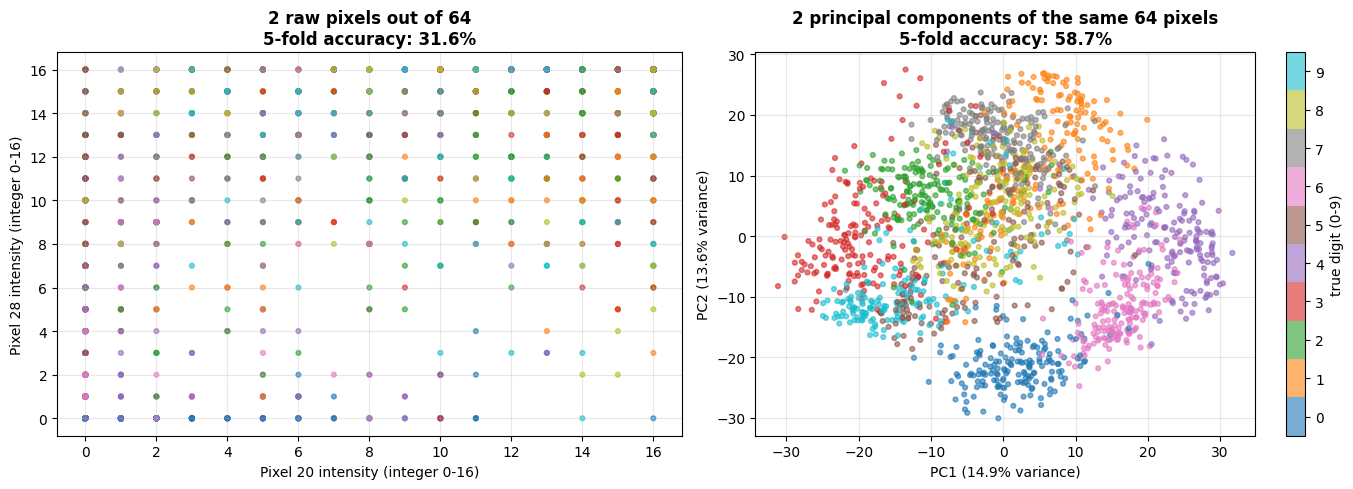


3. Key Insights:
   ✅ Reduced from 64 to 2 dimensions
   ✅ Those 2 components keep 28.5% of the variance
   ✅ Two raw pixels support 31.6% accuracy; two principal components
      support 58.7% (random guessing among 10 digits would give 10%)
   ✅ Faster computation for downstream ML models

4. Implications for Machine Learning:
   📊 Data Preprocessing: PCA is often a crucial preprocessing step
   ⚡ Performance: Faster training with fewer dimensions
   🎯 Generalization: Reduced dimensions can improve model generalization
   🔍 Interpretability: Lower dimensions make models more interpretable
   💾 Storage: Less memory needed for storing and processing data

5. When to Use Dimensionality Reduction:
   ✅ High-dimensional data (many features)
   ✅ Need for visualization
   ✅ Computational efficiency is important
   ✅ Want to reduce noise in data
   ⚠️  But be careful: dropping to 2D here threw away 71% of the variance!

💡 Remember: Dimensionality reduction is a tool, not always necessary!


In [4]:
# Example: Analyzing Results and Understanding Implications
# This demonstrates what happens AFTER applying dimensionality reduction

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

print("=" * 60)
print("AFTER: Understanding the Impact of Dimensionality Reduction")
print("=" * 60)

# Real high-dimensional data: 1797 scanned handwritten digits, each an 8x8 image
# flattened into 64 pixel intensities. Neighbouring pixels are highly correlated in
# real handwriting - that redundancy is what PCA compresses.
digits = load_digits()
X, y = digits.data, digits.target

print(f"\n1. Original Data:")
print(f"   Dimensions: {X.shape}")
print(f"   Features: {X.shape[1]} pixel intensities per image")
print(f"   Samples: {X.shape[0]} handwritten digits (classes 0-9)")

# Apply PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

print(f"\n2. After PCA (Dimensionality Reduction):")
print(f"   Reduced dimensions: {X_reduced.shape}")
print(f"   Explained variance ratio: {pca.explained_variance_ratio_.round(4)}")
print(f"   Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Measure the two panels BEFORE drawing them, so each panel can be labelled with the
# accuracy it actually supports - the figure then carries the claim instead of decorating it.
acc_pixels = cross_val_score(LogisticRegression(max_iter=5000), X[:, [20, 28]], y, cv=5).mean()
acc_components = cross_val_score(LogisticRegression(max_iter=5000), X_reduced, y, cv=5).mean()

# Visualize the transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data (two raw pixels). Pixel intensities are integers 0-16, so the points land
# on a lattice and pile up on top of each other - that pile-up IS the problem.
axes[0].scatter(X[:, 20], X[:, 28], c=y, cmap='tab10', alpha=0.6, s=12)
axes[0].set_title(f'2 raw pixels out of 64\n5-fold accuracy: {acc_pixels:.1%}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pixel 20 intensity (integer 0-16)')
axes[0].set_ylabel('Pixel 28 intensity (integer 0-16)')
axes[0].grid(True, alpha=0.3)

# Reduced data (PCA components)
scatter = axes[1].scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='tab10', alpha=0.6, s=12)
axes[1].set_title(f'2 principal components of the same 64 pixels\n5-fold accuracy: {acc_components:.1%}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].grid(True, alpha=0.3)

# Discrete colourbar: the label is a digit class, not a quantity, so show integer ticks only.
cbar = fig.colorbar(scatter, ax=axes[1], ticks=range(10))
cbar.set_label('true digit (0-9)')
scatter.set_clim(-0.5, 9.5)

plt.tight_layout()
plt.show()

print("\n3. Key Insights:")
print(f"   ✅ Reduced from {X.shape[1]} to {X_reduced.shape[1]} dimensions")
print(f"   ✅ Those 2 components keep {pca.explained_variance_ratio_.sum():.1%} of the variance")
# (both accuracies were measured above, before the figure, and are printed on its panels)
print(f"   ✅ Two raw pixels support {acc_pixels:.1%} accuracy; two principal components")
print(f"      support {acc_components:.1%} (random guessing among 10 digits would give 10%)")
print("   ✅ Faster computation for downstream ML models")

print("\n4. Implications for Machine Learning:")
print("   📊 Data Preprocessing: PCA is often a crucial preprocessing step")
print("   ⚡ Performance: Faster training with fewer dimensions")
print("   🎯 Generalization: Reduced dimensions can improve model generalization")
print("   🔍 Interpretability: Lower dimensions make models more interpretable")
print("   💾 Storage: Less memory needed for storing and processing data")

print("\n5. When to Use Dimensionality Reduction:")
print("   ✅ High-dimensional data (many features)")
print("   ✅ Need for visualization")
print("   ✅ Computational efficiency is important")
print("   ✅ Want to reduce noise in data")
print(f"   ⚠️  But be careful: dropping to 2D here threw away "
      f"{1 - pca.explained_variance_ratio_.sum():.0%} of the variance!")

print("\n" + "=" * 60)
print("💡 Remember: Dimensionality reduction is a tool, not always necessary!")
print("   Use it when it helps, but don't over-reduce if you need all features.")
print("=" * 60)


**Read the figure above.** Left: the same 1,797 digit images described by two of their raw
pixels. Because a pixel intensity is an integer from 0 to 16, the points fall on a lattice — all 1,797
images occupy only **234 distinct positions**, and 207 of them sit on the single dot at (16, 16). Colours
are shuffled together with no structure to see. Right: the same images described by their first two
principal components. Coloured islands appear — **0 in blue at the bottom, 6 in pink at the bottom right,
4 in purple on the right** — while the centre stays a mush where **5 (brown)** and **8 (olive)** sit on top
of each other. The panel titles carry the measurement rather than an impression: two raw pixels support
31.6% cross-validated accuracy, two principal components support 58.7%, against 10% for guessing. The
right panel is still far from clean, and that is what "2 components keep only 28.5% of the variance"
looks like.

---

## ⚠️ Where this breaks

- **Read the compression honestly — this notebook already does.** Thirty measurements of a tumour reduced
  to 2 components kept **63.2%** of the variance; to reach 95% you need **10 of the 30**. Sixty-four pixels
  reduced to 2 components kept **28.5%** — dropping to 2D discarded 71% of the variation in the images.
  Dimensionality reduction is a trade, and the printed variance ratio is the price tag. A tutorial that
  reduces 30 dimensions to 2 and keeps 99% has shown you a simulated dataset.
- **Variance explained is not usefulness.** The digit experiment prints the number that actually matters:
  two raw pixels support 31.6% classification accuracy, two principal components support 58.7% (random
  guessing among ten digits gives 10%). That is the honest comparison — an accuracy, on a task — and it is
  a different question from "how much variance survived."
- **The volume demonstration is about *uniform* data, and your data is not uniform.** The opening cell
  computes 0.9^d and concludes high-dimensional space is empty. True — for points spread uniformly through
  a hypercube. Real images, real text and real gene-expression data lie close to a much lower-dimensional
  surface inside that space, which is precisely why 64-pixel digits need only 29 components for 95% of
  their variance, and why deep learning on million-pixel photographs works at all. The curse is real; it is
  not a proof that high-dimensional learning is impossible.
- **PCA fitted before splitting leaks.** Every cell here fits PCA on the whole dataset. That is fine for a
  demonstration and wrong for an evaluation: the components have seen your test rows. In a real pipeline
  PCA goes inside a `Pipeline` so it is refitted on each training fold.


---

## 💬 Discuss

1. Two principal components raised digit accuracy from 31.6% (two raw pixels) to 58.7%, while throwing away
   71% of the variance. Reconcile those two facts — how can discarding most of the variation make the data
   *more* useful?
2. Eigenfaces made face recognition practical, and face recognition has since become one of the most
   contested applications of AI. Does responsibility for that trajectory reach back to a 1991 paper on
   matrix decomposition? Argue a position.
3. Ten of thirty components for 95% variance is a 3× compression. Name the specific circumstance in which
   you would take that trade, and the specific circumstance in which you would keep all thirty features
   instead.


### Common Pitfalls and How to Avoid Them

**Common Pitfalls and How to Avoid Them:**

1. **Over-Reducing Dimensions**: Reducing too many dimensions can lose important information
   - **Solution**: Always check explained variance ratio and keep enough components to preserve 80-95% of variance

2. **Not Standardizing Data**: PCA is sensitive to feature scales, leading to incorrect principal components
   - **Solution**: Always standardize (normalize) your data before applying PCA using StandardScaler

3. **Applying PCA to All Data**: Using PCA on test data separately can cause data leakage
   - **Solution**: Fit PCA only on training data, then transform both training and test data using the same fitted PCA

4. **Ignoring Interpretability**: PCA components are linear combinations and may be hard to interpret
   - **Solution**: Consider feature selection methods if interpretability is crucial for your use case

### Advanced Topics

**Advanced Topics for Further Learning:**

- **Kernel PCA**: Non-linear dimensionality reduction using kernel methods for non-linearly separable data
- **t-SNE and UMAP**: Advanced non-linear dimensionality reduction techniques for visualization
- **Incremental PCA**: Memory-efficient PCA for very large datasets that don't fit in memory
- **Sparse PCA**: PCA with sparsity constraints for feature selection and interpretability
- **Autoencoders**: Neural network-based dimensionality reduction for complex non-linear patterns

---

# Summary

## Key Takeaways

## Key Takeaways

In this module, you've learned how to handle high-dimensional data and extract the most important information:

1. **Curse of Dimensionality**: You discovered that as dimensions increase, data becomes sparse, distances become similar, and models struggle. High-dimensional spaces require exponentially more data. Dimensionality reduction addresses this by finding lower-dimensional representations that preserve essential information.

2. **PCA (Principal Component Analysis)**: You learned that PCA finds the directions of maximum variance in data using eigenvalue decomposition (from Module 01). The first principal component captures the most variance, the second captures the next most (orthogonal to the first), and so on. By keeping only the top components, you reduce dimensions while preserving most information. PCA is linear, interpretable, and widely used.

3. **Feature Selection vs Feature Extraction**: You understood two approaches: feature selection (choosing existing features) and feature extraction (creating new features like PCA components). Both reduce dimensions, but extraction can create more informative representations. The choice depends on whether interpretability (selection) or information preservation (extraction) is more important.

4. **Visualization and Efficiency**: You saw that dimensionality reduction enables visualizing high-dimensional data in 2D/3D plots, helping you understand data structure. More importantly, it speeds up training, reduces memory usage, and can improve model generalization by removing noise and redundant information. It's often a crucial preprocessing step in ML pipelines.

## 🔗 How This Connects to Other Modules

**What you learned here combines:**

- **Module 01**: **Eigenvalues/eigenvectors** → The mathematical foundation of PCA
- **Module 02**: **Gradient concepts** → Foundation for optimization (used in Module 03)
- **Module 03**: **Optimization** → Finding optimal reduced dimensions
- **Module 05**: **Statistical evaluation** → Evaluating the quality of reduced representations

> 💡 **The Complete Picture**: 
> - Module 01: Eigenvalues (the math)
> - Module 03: Optimization (the method)
> - Module 04: PCA (the application) ← **You are here!**
> - Module 05: Statistical evaluation (the validation)

**You've now seen how linear algebra + optimization = powerful dimensionality reduction!**

## Next Steps

1. Complete the exercises in the `exercises/` folder
2. Review the solutions if needed
3. Move on to **Module 05: Probabilities, Samples, and Statistical Inference**
   - You'll learn how to evaluate models and make statistical inferences
   - **Connection**: Use statistics (from Module 03) to evaluate the reduced data (from this module)

---

**Ready for exercises?** Navigate to the `exercises/` folder and start practicing!

## 📚 References

1. Pearson, K. (1901). *On Lines and Planes of Closest Fit to Systems of Points in Space*. Philosophical Magazine, 2(11), 559–572.
2. van der Maaten, L., & Hinton, G. (2008). *Visualizing Data using t-SNE*. Journal of Machine Learning Research, 9, 2579–2605. <https://jmlr.org/papers/v9/vandermaaten08a.html>
3. Jolliffe, I. T., & Cadima, J. (2016). *Principal Component Analysis: A Review and Recent Developments*. Philosophical Transactions of the Royal Society A, 374(2065). <https://doi.org/10.1098/rsta.2015.0202>
4. Zhang et al. (2025). *Qwen3 Embedding: Advancing Text Embedding and Reranking Through Foundation Models*. arXiv. <https://arxiv.org/abs/2506.05176> — the 2026 alternative to computing a representation: use a pretrained encoder's.
5. Jeon, H., Park, J., Shin, S., & Seo, J. (2025). *Stop Misusing t-SNE and UMAP for Visual Analytics*. arXiv. <https://arxiv.org/abs/2506.08725> — a 136-paper review of how projections from this module get over-read.
